<a href="https://colab.research.google.com/github/KunjalGarg27/Smartphone-Addiction-Prediction-Using-Machine-Learning/blob/random-forest-branch/RandomForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ZIP extracted!
CSV files found: ['Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv']

Shape: (7500, 16)

Columns:
 Index(['transaction_id', 'user_id', 'age', 'gender', 'daily_screen_time_hours',
       'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'stress_level', 'academic_work_impact', 'addiction_level',
       'addicted_label'],
      dtype='object')

First 5 rows:
   transaction_id user_id  age gender  daily_screen_time_hours  \
0       TXN00001  U00001   21   Male                     3.23   
1       TXN00002  U00002   24  Other                     5.09   
2       TXN00003  U00003   31  Other                     6.06   
3       TXN00004  U00004   32  Other                     7.83   
4       TXN00005  U00005   25   Male                     9.96   

   social_media_hours  gaming_hours  work_study_hours  sleep_hours  \
0                2.01          0.89              4.55

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression Accuracy: 1.0

Random Forest Accuracy: 1.0

Best Random Forest Accuracy: 1.0
Best Parameters: {'max_depth': 5, 'n_estimators': 100}

Classification Report (Best RF):

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       265
           1       1.00      1.00      1.00      1072

    accuracy                           1.00      1337
   macro avg       1.00      1.00      1.00      1337
weighted avg       1.00      1.00      1.00      1337



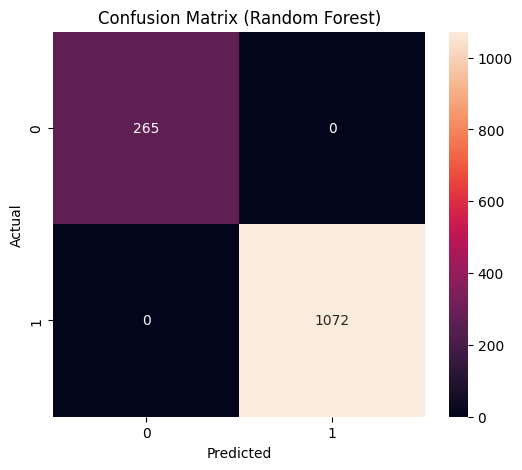

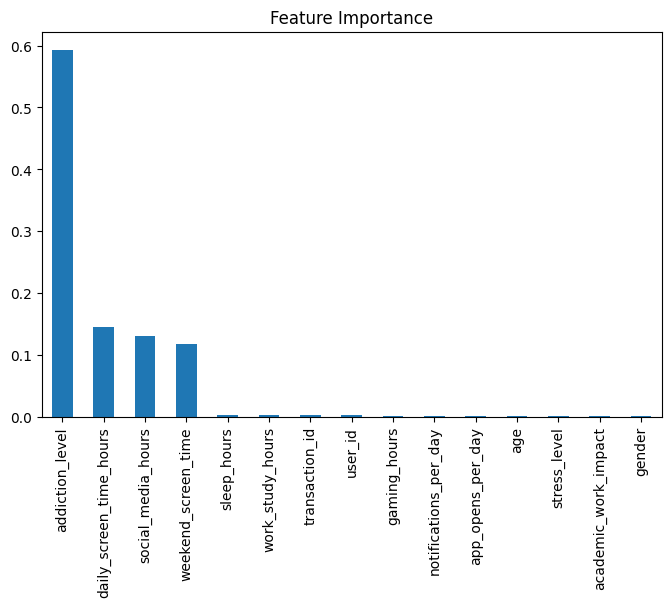

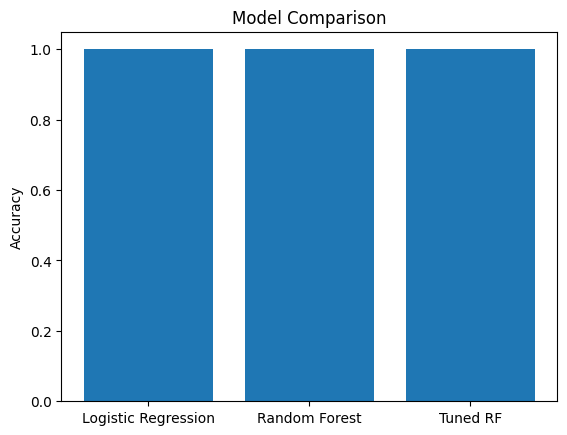

In [ ]:
# ==============================
# STEP 1: IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ==============================
# STEP 2: EXTRACT ZIP
# ==============================
zip_path = '/content/archive (1)-3.zip'

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('/content/')
    print("ZIP extracted!")

# ==============================
# STEP 3: LOAD DATASET
# ==============================
files = os.listdir('/content/')
csv_files = [f for f in files if f.endswith('.csv')]

print("CSV files found:", csv_files)

df = pd.read_csv('/content/' + csv_files[0])

# ==============================
# STEP 4: BASIC INFO
# ==============================
print("\nShape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nFirst 5 rows:\n", df.head())

# ==============================
# STEP 5: DATA CLEANING
# ==============================
df = df.dropna()

# ==============================
# STEP 6: ENCODING
# ==============================
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col].astype(str))

# ==============================
# STEP 7: TARGET COLUMN
# ==============================
target_column = df.columns[-1]   # last column assumed target
print("\nTarget column:", target_column)

X = df.drop(target_column, axis=1)
y = df[target_column]

# ==============================
# STEP 8: TRAIN-TEST SPLIT
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# STEP 9: LOGISTIC REGRESSION (COMPARISON)
# ==============================
log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
log_acc = accuracy_score(y_test, y_pred_log)

print("\nLogistic Regression Accuracy:", log_acc)

# ==============================
# STEP 10: RANDOM FOREST (BASE)
# ==============================
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, y_pred_rf)

print("\nRandom Forest Accuracy:", rf_acc)

# ==============================
# STEP 11: HYPERPARAMETER TUNING
# ==============================
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3)
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

y_pred_best = best_rf.predict(X_test)
best_acc = accuracy_score(y_test, y_pred_best)

print("\nBest Random Forest Accuracy:", best_acc)
print("Best Parameters:", grid.best_params_)

# ==============================
# STEP 12: CLASSIFICATION REPORT
# ==============================
print("\nClassification Report (Best RF):\n")
print(classification_report(y_test, y_pred_best))

# ==============================
# STEP 13: CONFUSION MATRIX
# ==============================
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ==============================
# STEP 14: FEATURE IMPORTANCE
# ==============================
importance = best_rf.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importance, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(8,5))
feat_imp.plot(kind='bar')
plt.title("Feature Importance")
plt.show()

# ==============================
# STEP 15: MODEL COMPARISON GRAPH
# ==============================
models = ['Logistic Regression', 'Random Forest', 'Tuned RF']
accuracy = [log_acc, rf_acc, best_acc]

plt.figure()
plt.bar(models, accuracy)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()